# Matplotlib - Advanced Customization
___
- EG: `import adjust_text`
- Before moving any further and Exploring other Plots such as Histograms and Box Plots, we need to get more familiar with how we can Customize all of these different Plots
- For the first half of the Lesson:
    - We will Focus on a Line Chart that we Created previously that shows the **Top 5 Skills for Data Analysts Per Month**
        - This shows the Trend of Skills over time
        - Specifically looking at all the different Parameters that can be Adjusted on it in order to make the Visualizations pop more!
    - Important to Note, everything that we can Apply on this Line Chart, can be similarly Applied to other Charts as well!
    - This will go to good use on all the Visualizations
- For the second half of the Lesson:
    - We will look at the Scatter Plot that we made in the Previous Lesson
    - We will be Upgrading it, with what we learn in this Lesson!
        - Updating the Lables so that they aren't sitting on top of each other
        - Updating the Y Axis, so that the Format is cleaner and easier to read
- All of the Analysis in this Lesson will be specific to Data Analyst so we will be Filtering the DataFrame down to only have Job Postings where the Job Title is Data Analyst
    - It's just easier to handle the Data that way and also adding it to our usual Data Importing gets that part of the Code out of the way
- Let's do our Customary Data Imports and Cleanups along with Bringing that Chart over from 45_Exercise - Trending Skills and making it in here

In [1]:
# Imports
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skills: ast.literal_eval(skills) if pd.notna(skills) else skills)

# Filtering for Data Analyst Job Data
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()

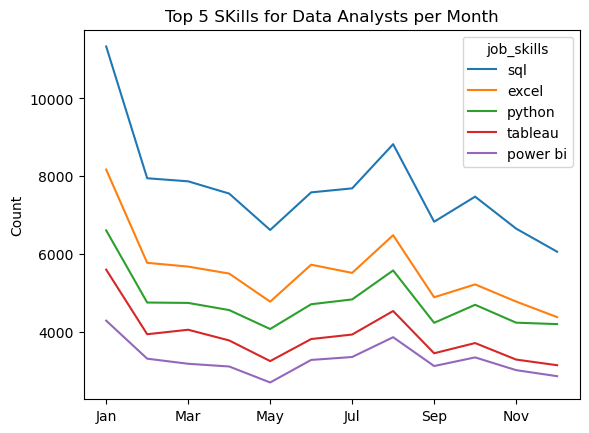

In [11]:
# Chart over from 45_Exercise - Trending Skills

# Create a New Column for Month Number
df_DA['job_posted_month_no'] = df_DA['job_posted_date'].dt.month

# Explode the job_skills Column and Pivot
df_DA_explode = df_DA.explode('job_skills')
df_DA_pivot = df_DA_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)

# Sort the skills by Count
df_DA_pivot.loc['Total'] = df_DA_pivot.sum()
df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending=False).index]
df_DA_pivot = df_DA_pivot.drop('Total')

# Use Month Names for Plotting
df_DA_pivot = df_DA_pivot.reset_index()
df_DA_pivot['job_posted_month'] = df_DA_pivot['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_pivot = df_DA_pivot.set_index('job_posted_month')
df_DA_pivot = df_DA_pivot.drop(columns='job_posted_month_no')

# Get the Top 5 Skills
df_DA_pivot.iloc[:, :5].plot(kind='line')

# Visualization Cleanup
plt.title('Top 5 SKills for Data Analysts per Month')
plt.xlabel('')
plt.ylabel('Count')
plt.show()

- As a Refresher, here's what the above Code is doing:
    - The DataFrame itself is Columns with the Job SKills
    - For each of the Rows it's Indexed by the Job Posted Month Short String Value
    - It's all Sorted in order of the Highest Requested Skill down to the least
    - And then it's Plotted in a Line Chart but we only Plotted the Top 5 Skills
- Now, let's get into Customizing this Line Chart!
    - We will be Focusing on the Line Chart Area itself, we won't be looking at the Title, or the Labels on the X and Y Axis at the minute
        - We are just going to leave those as is
    - For the Final Visualization, we will be Customizing all the different Parameters
- Let's Start off with the Original Graph

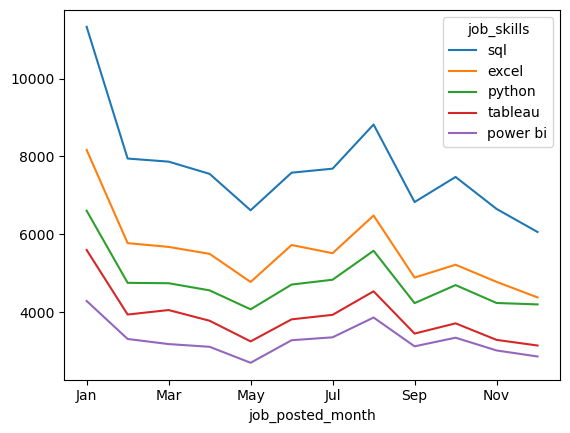

In [13]:
# Original Graph
df_DA_pivot.iloc[:, :5].plot(kind='line')
plt.show()

- Because we are going to have mutiple Parameters passed into the `.plot()` Function, we will break it up and add them each as an individual Line
- Don't forget to separate the Lines using Commas at the end of each Line as these are still needed when Passing in multiple Arguments
- This will make it easier to Read and stop the Function from getting too long and having a Scroll bar on it
    - We will Start off with the Open Bracket following the Function like so: `.plot(` then every line we will add a New Parameter to Pass in
    - First thing we pass in is the **Kind** as always which will be the Kind of Graph we Draw to the Screen, using: `kind='line`
    - Because it's a Line, we can Pass in the **Line Width** which makes the Line thicker, using: `linewidth=4`
        - This thickness really makes the Chart pop
    - Next up is **Line Style**, this will control how the Line's on the Chart are drawn. To make it a bunch of Dots, use: `linestyle=':'`
        - The different Options are: `'-', '--', '-.', ':'`
    - Next is the **Colour**. Right now, the Lines are using the Standard Matplotlib Colour Mapping. Time to Provide a different Colour Mapping using: `colormap='viridis'`
        - There are Multiple different Colour Maps that can be Provided. To find them look at the [Cheatsheet](https://matplotlib.org/cheatsheets/) and it will have all the different Colour Maps in there
    - Next is the **Markers**, We can Identify a Marker by how we want to Plot it, for this we will use: `marker='o'`. Now the Markers are using Dots
        - There are many different Options such as: `'o', 'x', '+', '*', 's', ',', '.', '1', '2', '3', '4', ...`
        - Common ones are `'o'` and `'*'`
    - Next is the **Marker Size**, We are going to make this big so it stands out, and we will have to make it slightly bigger than our line, do this by using: `markersize=5`
    - Next is the **Figure Size**, this specifies the Width, along with the Height. For this we will make it super long and super short, using: `figsize=(10,5)`
    - Ending with `)` for the Plot Function
- Then underneath all this we Add back in our Title, X and Y Labels and the Show Function

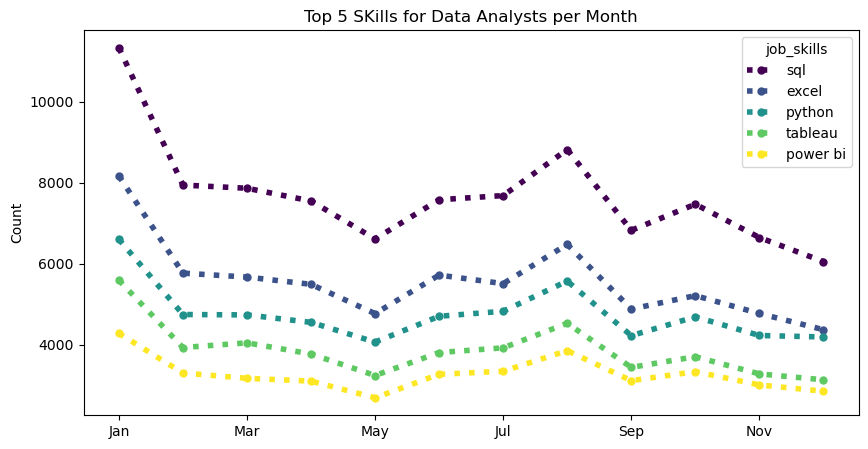

In [14]:
# Customizing the Graph
df_DA_pivot.iloc[:, :5].plot(
    kind='line', 
    linewidth=4,
    linestyle=':',
    colormap='viridis',
    marker='o',
    markersize=5,
    figsize=(10,5)
) 
plt.title('Top 5 SKills for Data Analysts per Month')
plt.xlabel('')
plt.ylabel('Count')
plt.show()

- We now have the Final Visualization which doesn't look bad at all!
- Since this is all the Parameters for a Line Chart:
    - If curious about all the different Parameters that can be provided to this
        - Just need to change the Plot Type that's being drawn in the `kind=` Argument
        - Then go to the Applicable Plot that's being Called via Matplotlib
        - While we are using the `.plot()` Function of Pandas, we are Graphing is using the `line` Plot Method from Matplotlib
    - To check all the different Parameters that can be provided, for a Bar Chart Plotting it via Pandas
        - Access the Matplotlib Library, under the `pyplot` Module, scrolling down there, to see all the different Parameteres
        - A lot of the same Parameters from the Line Chart, are also in here, such as `linewidth`
- Now, that the Line Chart is fully Customized and Finished with and we are happy with it
- Time to move into Customizing the Scatter Plot Chart that we did in the last lesson!!
    - Here, we just added all the Code that we worked on last lesson
    - The only change made was to Explicitly Call how many Skills that's being Plotted on the Scatter Plot
        - Specifically, there will be 20, and then this will be Passed into the `.head()` Function that is used to Filter the DataFrame by the Amount of Skills shown
    - Last time, the DataFrame was being Filtered by 10, this time it has been Increased to Filter by 20. And there is a Reason for this
        - With only 10, there's no overlap... but when more get Added, there's a lot of overlap happening with the Skill Label Text and it's getting harder and harder to read this...
    - It's always good to set things as Variables, since they can always easily be Updated, rather than Updating everywhere you Set a Value
- Now let's actually bring in that Code from the Last Lesson and make the DataFrame and also Plot that Information so we can Customize it!

In [ ]:
# Scatter Plot: DataFrame
# Explode the job_skills into individual rows
df_exploded = df_DA.explode('job_skills')

# Calculate the Median Salary and Count of Job Postings per Skill
skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count=('job_skills', 'count'),
    median_salary=('salary_year_avg', 'median')
)

# Limit the Top Skills
skill_count = 20
skill_stats = skill_stats.sort_values(by='skill_count', ascending=False).head(skill_count)

# Printing out the DataFrame
skill_stats

,skill_count,median_salary
job_skills,,
sql,92428,92500.000000
excel,66860,84479.000000
python,57190,98500.000000
tableau,46455,95000.000000
power bi,39380,90000.000000
r,29996,92527.500000
sas,27998,90000.000000
powerpoint,13822,85000.000000
word,13562,80000.000000


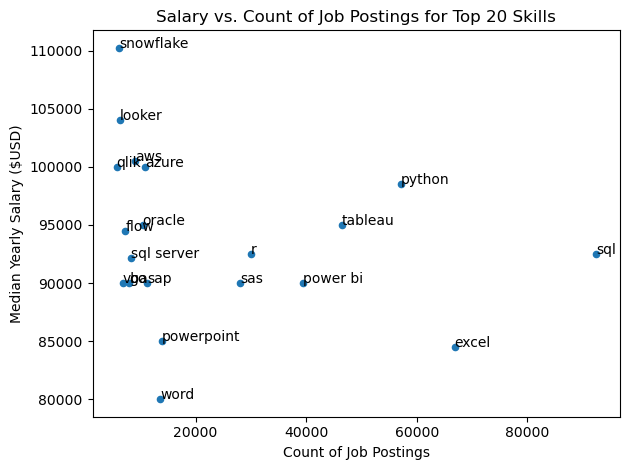

In [ ]:
# Scatter Plot: Scatter Plot Visualization using the plt.text() Function
skill_stats.plot(kind='scatter', x='skill_count', y='median_salary')

for i, txt in enumerate(skill_stats.index):
    plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt)

plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title(f'Salary vs. Count of Job Postings for Top {skill_count} Skills')
plt.tight_layout()
plt.show()

- What are we going to be working towards? How will this Visualization look at the end?
    - Updating the above Visualization to use a special Library
    - This ensures, there's no overlaps on the Skill Labels like above, and if there is, arrows are provided, pointing to the Associated dot with the Skill
- To Accomplish this, we are going to be using Adjust Text (adjustText)
    - Documentation can be found [here](https://adjusttext.readthedocs.io/)
    - Made to Provide the Function `adjust.Text.adjust_text()`
        - Whole purpose of this Library is to do, just that! Adjusts the Text
        - Passing in the Arguments:
            - **Text**: A List of `matplotlib.text.Text` Objects to adjust
                - This is going to be pretty similar to the Method used last Lesson with the `plt.text()`
    - First the Library needs to be Installed, using the Terminal and making sure we are using the correct Python Environment
        - Install the Library using `conda install adjustText`
    - If that doesn't work use the Following in a Python Cell: `!pip install adjustText`
    - Now to Import in the Function
        - To do this, use: `from adjustText import adjust_text`
    - Now that it's Installed, we aren't going to start over regarding the Scatter Plot, since there's no point
        - We are just going to take all of the above Code and Paste it below so we can Start work on making the Labels all nice

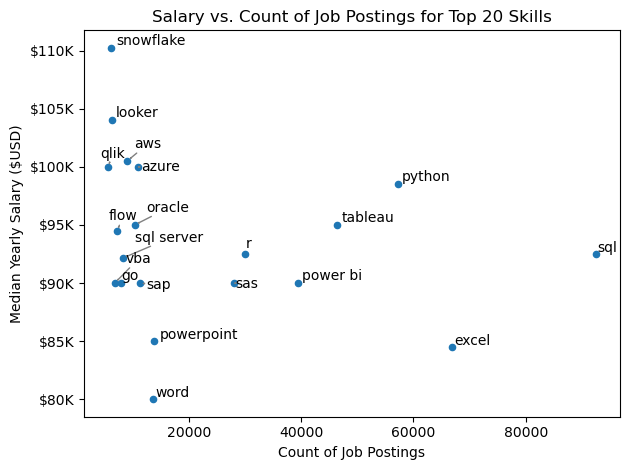

In [ ]:
# Scatter Plot: Scatter Plot Visualization using the New adjust_text() Function

# New Import
from adjustText import adjust_text

skill_stats.plot(kind='scatter', x='skill_count', y='median_salary')

# Creating an Empty List
texts = []

for i, txt in enumerate(skill_stats.index):
    # Appending the Labels into the List Variable
    texts.append(plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt))
# Drawing the Arrows from the Labels to the dots, using the List of Labels and Drawing those arrows
adjust_text(texts, arrowprops=dict(arrowstyle="->", color='gray', lw=1))

# Accessing the Axis Object
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))

plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title(f'Salary vs. Count of Job Postings for Top {skill_count} Skills')
plt.tight_layout()
plt.show()

- Create a List so that it can be Passed into the `adjust_text()` Function
    - Putting it under where we Plot the Scatter Chart
    - Initialize it by calling it: `texts` and making it equal an Empty List like so `= []`. In full we have: `texts = []`
    - This List is a List of all of the different `plt.text()` Calls... that has the X and Y Value and also the actual Text Label Value inside `txt`. Basically what we want for the text
    - So we need to Insert this or `append` this `plt.text()` Function into our List Variable `texts = []`
    - This is pretty easy. To do this: add to the front of the `plt.text()` Function: `texts.append()` and Pass in the `plt.text()` Function and it's contents inside of the `.append()`
        - Add `texts.append` to the front of `plt.text()` and wrap the entire thing in parenthesis `()`
        - You will have: `texts.append(plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt))`
- Now it's time to use the `adjust_text()` Function!
    - We will put it in, below where we are Generating all of the Text from the `plt.text()` Function but outside of the `for` Loop
    - Start by initializing: `adjust_text()`
    - The Argument we are Passing in is the first Argument of `texts`, which is a List
- After including this and Running it, there's now no overlap happening anymore and some Labels got moved... but you can't tell which Label belongs to which dot...
- This is where we will need some Arrows to explain that
    - Going back to the Documentation to see what we need to make this happen
    - Looking at all the different Visualizations in here and seeing what we want to use
        - In this case, we want to use the `arrowprops=` Parameter
        - Using this to Specify what we want to point to
        - This Argument goes inside of the `adjust_text()` Function. It will go after the List Argument of `texts`
        - Now we have Arrows pointing to the dots! Just a bit of Cleanup needed with the Colours and the Line Width
            - `arrowprops=dict()`
                - Inside here Passing:
                    - `arrowstyle="->"`
                    - `color='gray'`
                    - `lw=1`
                    - Afterwards, it will look like: `arrowprops=dict(arrowstyle="->", color='gray', lw=1)`
- Running all of this we now have Arrows pointing from the Label to the dot, now we know which dot belongs to which Label
- Much better representation of the Data Set
- Last thing we need to do as part of the Cleanup is to Customize the Y Axis
    - Specifically better Format the Values to be $ then the first 3 Digits of the Thousands and specifying that it's the Thousands by adding in a K Value at the end
    - We do this because it's more representistic of what the Data is showing and makes it look more polished and Professional
    - Compared to the Long Numbers that we have in the previous iterations of the Visual
    - In order to do this, the Class of `FuncFormatter` needs to be initialized
        - `class matplotlib.ticker.FuncFormatter(func)`
        - Inside of it, we will need to Provide a Function, we will Provide a `lambda` Function to make it easy
            - This Function takes in 2 Inputs:
                - A tick value `y`
                - A position `pos` 
            - Returns a String containing the coresponding tick label, reason why it's under `ticker`
    - Let's get into Modifying this, using the `FuncFormatter`
        - We will be Modifying the Axis, and not Modifying the Figure itself
        - We will need to Access that Axis Element/Object
        - We can do this 2 different ways...
            1. `fig, ax = plt.subplots()`
                - Passing in no Arguments, and now we have Access to the Axis Object through `ax`
            2. `ax = plt.gca()`
                - Inside of the `pyplot` Module, we have a Function called Get Current Axis or `.gca()`. This will also give us Access to the Axis Object
        - We will use the Second Option as it makes the most sense, since we don't need to use `fig` at all so there's no point in initializing it
        - One Problem we have with the Function Call of `ax = plt.gca()` is if we only Add it in and don't Call it, the Scatter Plot Visual will completely disappear
        - We have to Call it after we Generate the Plot
            - To do this, we Call it underneath our `for` loop, undearneath the section where we Added the `adjust_text` Function that Creates Arrows from the Labels to the dots
            - Adding it in here by Setting the `ax` Variable equal to the `plt.gca()` Function, this will look like: `ax = plt.gca()`
                - All we are doing is, moving this Line, `ax = plt.gca()`, that we had at the very Top of our Program, to underneath the `for` loop and `adjust_text()` Function
                - It is important to pay attention to where to Add specific Lines of Code, otherwise it can mess the entire Program up and cause Visualizations not to be drawn/appear to the Screen
        - Once we have Added it into the Appropriate Spot, now we are Calling the Axis itself
        - Running again, with it in the correct Location, we get all our Values and Visual back...
        - The point of all of this is because
            - We want the Y Axis of this Axis Object
            - To get that, we need to:
                - Call out the `ax` Variable
                - Using the `.yaxis` Method
                - Then Calling the `.set_major_formatter()` Function
                - All together it will look like: `ax.yaxis.set_major_formatter()`
                    - Inside of here, is where we will pass in the Argument of `plt.FuncFormatter()`
                        - Inside of here, is where we will pass in the Argument of a Function... specifically a `lambda` Function
                            - With the `lambda` Function we will use 2 Arguments, `y` and `pos`
                                - Printing only the `y` so we can see what changes: The Labels change to a Floating Point Number
                                - We are providing the Number back, that's what's inside of this `y` Argument
                                - Printing only the `pos` so we can see what changes: The Labels change to the Index Value of each of these Tick Marks
                                - The Index of the tick Marks is what's inside of this `pos` Argument, basically the sequence starting at 1 and Incrementing up, counting the ticks we have
                                    - We don't need to know this and don't care about `pos` but we have to Call it...
                                - Afterwards, it will look like: `ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: y))` 
                            - Now we have our `y` Value all we need to do is Format this Axis!
                                - Easy way of doing this, is just Passing it in via an **f string**
                                    - Like so: `f'${y}K'`
                                    - This Adds a **$** to the beginning of the Y Axis Value, while also adding a **K** to the end of it
                                    - Last thing to do is to cut off the Decimal Places and also the last 3 Zero's as well
                                    - We can take our `y` Value, Divide it by 1000: `f'${y/1000}K'`. This gets rid of the 3 Zeroes but we still have the Decimal point left hanging around
                                    - To get rid of this, we will need to Convert this Operation that we are doing, into an **int**, this will make the decimal point fall off
                                    - This will look like `f'${int(y/1000)}K'`
                            - Afterwards, it will look like: `ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))`
        - Finally... after Running all this we now get what we want! Yippee!!!
        - The Y Axis is now Formatted exactly how we need it with the 2-3 Values in between the $ and K Characters that we Added in that indicate Thousands in the Dollars
        - We can actually also Format the X Axis as well... but in the Future, we will be changing this to a Percentage based on the Skill Percentage, based on all Job Postings
            - Because of that, there's no point in cleaning it up right now, since we will be changing this later